# 비침습 입력을 이용한 대사 소견 분류 모델 비교

2020–2024년 국민건강영양조사에서 여러 분류 모델의 성능을 같은 대상자·입력·분할 조건에서 비교했다. 기존 통계·트리·신경망 모델과 함께 직접 구현한 EPF도 비교 대상에 포함했다. 이 노트북은 공개 집계 결과의 표와 그림을 재생성하며 개인별 원자료를 읽거나 모델을 재학습하지 않는다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "paper/results/comparison_summary.json").is_file())
paper = repo / "paper"
summary = json.loads((paper / "results/comparison_summary.json").read_text(encoding="utf-8"))
print("기간:", summary["years"])
print("연령:", summary["age"])
print("공통 대상자:", summary["cohort"]["nutrition_20_39"])
print("비침습 입력:", summary["predictor_count"], "개")
display(pd.Series(summary["cohort"]["by_class"], name="n").to_frame())

기간: [2020, 2021, 2022, 2023, 2024]
연령: [20, 39]
공통 대상자: 4508
비침습 입력: 15 개


,n
Normal,2796
High_BP,183
High_Glu,233
Dyslipid,813
Complex,483


## 연구 정의

29개는 원자료 선택 열 수이고 예측 입력은 15개다. 검사값과 진단 항목은 입력으로 사용하지 않았다. 혼밥·체중 증가 코드를 수정하고 전처리는 학습 역할에서만 적합했다. 저녁 동반 식사 문항을 사용하므로 영양조사 참여자와 wt_tot 가중치를 사용했다.

정상·혈압 단독·혈당 단독·지질 단독·복합의 5군이다. TG와 저HDL을 하나의 지질 영역으로 묶는다. 선정 기준과 전체 변수 사전은 [연구 정의 문서](01_study_definition.md)에 있다.

In [2]:
display(pd.DataFrame({"입력": summary["predictors"]}))
print("분할:", summary["split"])
print("튜닝:", summary["tuning"])
print("최종 seed:", summary["final_seeds"])
print("모델×분할:", summary["model_fold_units"], "/ 튜닝 포함 학습:", summary["fit_count"])

,입력
0,age
1,HE_BMI
2,HE_wc
3,WHtR
4,sedentary_hours
5,sex
6,incm
7,edu
8,sm_presnt
9,dr_month


분할: 5 year-balanced PSU-group outer folds; inner PSU fit/validation; same people for all models
튜닝: 8 settings per condition, selection seed 42; select by weighted validation macro AP
최종 seed: [42, 43, 44]
모델×분할: 40 / 튜닝 포함 학습: 390


## 모델 비교 결과

모든 모델에서 같은 5군 평가 지표를 계산했다. macro AP는 군별 조사 가중 AP를 같은 비중으로 평균한 값이다. 구간은 고정 예측의 PSU 재표집 구간이며 재학습 불확실성을 포함하지 않는다.

,Model,Description,macro_AP,AP_CI_low,AP_CI_high,macro_AUROC,macro_F1,balanced_accuracy,NLL,Brier
0,LR,로지스틱 회귀,0.34429,0.33353,0.35991,0.72820,0.27100,0.28586,0.99255,0.49366
1,RF,Random Forest,0.34392,0.33238,0.36047,0.72677,0.27394,0.29308,0.99098,0.49338
2,XGB,XGBoost,0.34934,0.33725,0.36557,0.73341,0.28430,0.30344,0.98422,0.48995
3,LGBM,LightGBM,0.35152,0.33902,0.36764,0.73214,0.28239,0.29907,0.98696,0.48980
4,MLP,MLP,0.34879,0.33748,0.36554,0.73197,0.27312,0.28963,0.98806,0.49198
5,jLinear,공동분포 선형 평균 모델,0.34441,0.33334,0.35961,0.73715,0.26068,0.28845,0.98853,0.49394
6,jMLP,공동분포 MLP,0.34850,0.33689,0.36445,0.73573,0.27458,0.30545,0.98497,0.49132
7,jEPF,EPF (공동분포),0.35148,0.33957,0.36754,0.73543,0.28287,0.30924,0.98572,0.49129


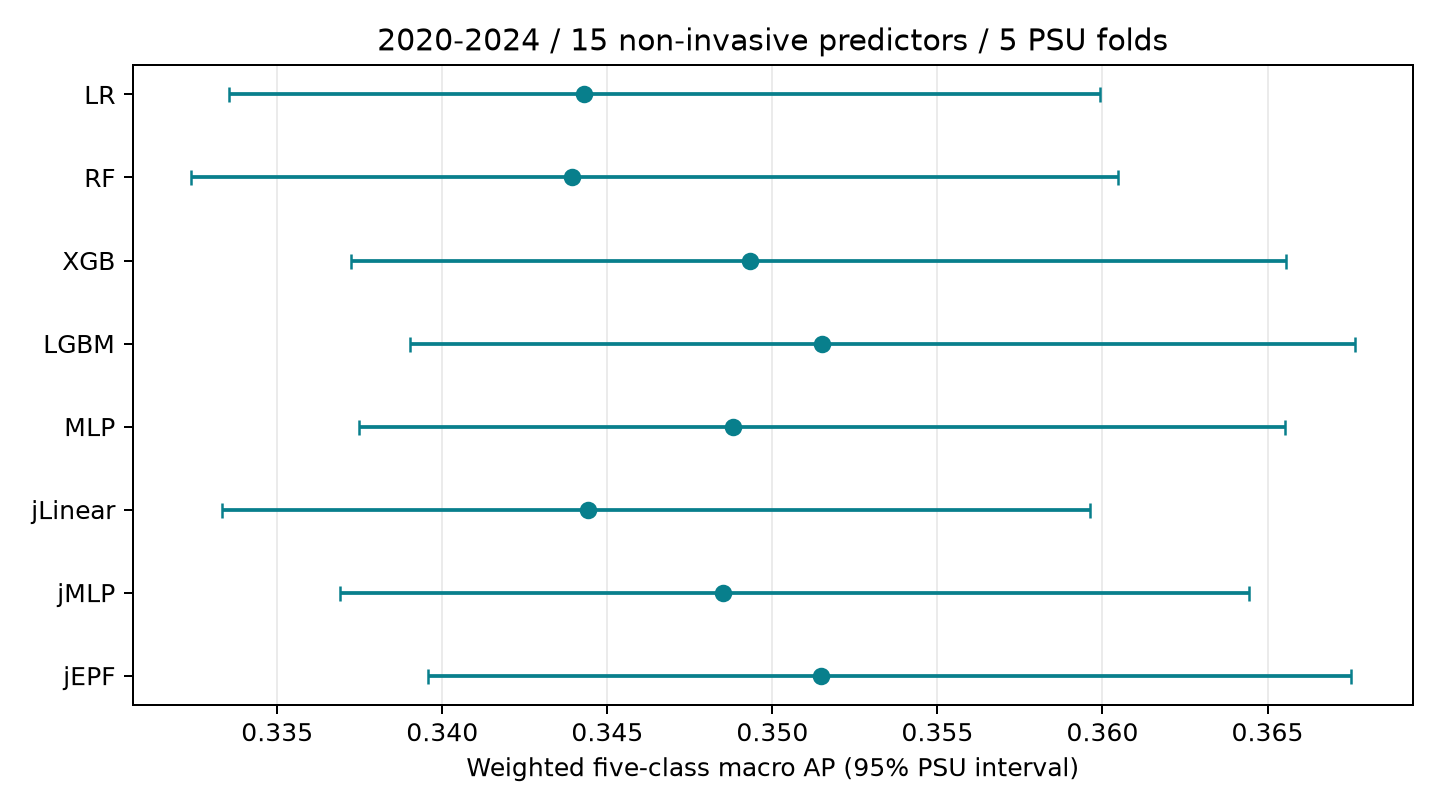

In [3]:
import importlib.util
spec = importlib.util.spec_from_file_location("paper_results", paper / "render_results.py")
results = importlib.util.module_from_spec(spec)
spec.loader.exec_module(results)
table = results.result_table(summary)
display(table.round(5))
display(Image(filename=str(paper / "results/model_comparison.png")))

## 비교 조건과 결과 해석

LR·RF·XGBoost·LightGBM·MLP는 5군을 직접 분류한다. 선형 평균 모델·MLP·EPF의 공동분포 방식은 5개 연속 검사값을 학습한 뒤 같은 5군 확률을 계산한다. 따라서 직접 분류기와의 차이에는 추가 학습 정보와 출력 설계의 차이도 포함된다. EPF는 이 비교에 포함한 직접 구현 신경망 중 하나다.

In [4]:
print(f"macro AP 범위: {table.macro_AP.min():.4f}–{table.macro_AP.max():.4f}")
display(table[["Model", "macro_AP", "macro_AUROC", "macro_F1", "NLL", "Brier"]].round(4))
print("지표에 따라 순위가 다릅니다. 이 표본의 결과를 일반적 모델 우수성이나 임상 효과로 확대하지 않습니다.")

macro AP 범위: 0.3439–0.3515


,Model,macro_AP,macro_AUROC,macro_F1,NLL,Brier
0,LR,0.3443,0.7282,0.2710,0.9926,0.4937
1,RF,0.3439,0.7268,0.2739,0.9910,0.4934
2,XGB,0.3493,0.7334,0.2843,0.9842,0.4900
3,LGBM,0.3515,0.7321,0.2824,0.9870,0.4898
4,MLP,0.3488,0.7320,0.2731,0.9881,0.4920
5,jLinear,0.3444,0.7372,0.2607,0.9885,0.4939
6,jMLP,0.3485,0.7357,0.2746,0.9850,0.4913
7,jEPF,0.3515,0.7354,0.2829,0.9857,0.4913


지표에 따라 순위가 다릅니다. 이 표본의 결과를 일반적 모델 우수성이나 임상 효과로 확대하지 않습니다.


## 군별 성능과 반복 변동

LR은 결정론적 한 모델이다. 다른 모델은 선택된 설정의 3개 seed 확률을 평균했다. 실험 단계의 사전 지정 대조 기록은 집계 JSON에 보존되어 있으며, 본문은 전체 모델 비교를 중심으로 구성한다.

In [5]:
rows = [{"Model": key, **row} for key, value in summary["metrics"].items() for row in value["classes"]]
display(pd.DataFrame(rows).pivot(index="Model", columns="class", values="ap").round(4))
display(pd.DataFrame.from_dict(summary["seed_macro_ap"], orient="index", columns=["seed42", "seed43", "seed44"]).round(5))

class,Complex,Dyslipid,High_BP,High_Glu,Normal
Model,,,,,
LGBM,0.4160,0.3169,0.0725,0.1138,0.8383
LR,0.4011,0.3011,0.0767,0.1037,0.8388
MLP,0.4099,0.3058,0.0838,0.1033,0.8411
RF,0.3976,0.2941,0.0744,0.1170,0.8365
XGB,0.4135,0.3117,0.0730,0.1088,0.8397
jEPF,0.4162,0.3196,0.0782,0.0996,0.8439
jLinear,0.3887,0.3107,0.0806,0.1000,0.8420
jMLP,0.4010,0.3139,0.0759,0.1069,0.8447


,seed42,seed43,seed44
LR,0.34429,NaN,NaN
RF,0.34263,0.34333,0.34441
XGB,0.34673,0.34868,0.35032
LGBM,0.35133,0.34918,0.34971
MLP,0.34853,0.34836,0.34900
jEPF,0.34904,0.34991,0.34875
jMLP,0.34724,0.34724,0.34829
jLinear,0.34466,0.34428,0.34429


## 논문 작성 시 연결할 부분

동료의 요인 분석과 대상자·라벨·가중치·변수 코드를 맞춘 뒤 전체 논문을 작성한다. 현재 모델 비교의 4,508명과 기존 탐색 분석의 다른 표본을 같은 결과처럼 합치지 않는다. 확인 항목은 [논문 작성 순서](03_writing_plan.md)에 정리되어 있다.

In [6]:
for item in summary["limitations"]:
    print("-", item)
print("집계 원문 SHA256:", summary["source_report_sha256"])

- Internal post-hoc comparison on previously examined KNHANES; not independent external validation
- Joint models additionally learn continuous measurements; direct-vs-joint differences are not pure architecture effects
- Single-seed tuning; three final seeds; fixed-prediction bootstrap does not include refitting uncertainty
- Corrected feature coding and strict unaware/fasting/pregnancy cohort differ from peer notebook
- No factor discovery, SHAP, causal or clinical-benefit claims
집계 원문 SHA256: 74200bd55fdffcce4264046eaa28cb02fad7292e6df750a6a3c2a1a5ea08fa6d
